In [65]:
# 📝 Scenario: Loan Approval Prediction (Multilayer Neural Network)
# Context
# Banks want to decide whether to approve a loan application. The decision depends on multiple factors, and the relationships are non-linear (not just a simple rule).
# Inputs (Features)
# Income level (normalized numeric value)
# Credit score (normalized numeric value)
# Output
# 1 = Loan approved
# 0 = Loan rejected
# Rule (intuitive, hidden from model)
# Higher income + good credit score → likely approved.
# Low income + poor credit score → likely rejected.
# Middle cases depend on combinations (non-linear patterns).

In [66]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [67]:
np.random.seed(42)
income = np.random.rand(500)     # values between 0 and 1
credit = np.random.rand(500)     # values between 0 and 1

# Combine features
X = np.column_stack((income, credit))

# Hidden non-linear approval logic (for simulation)
y = (0.6*income + 0.8*credit + 0.2*np.random.randn(500)) > 0.75
y = y.astype(int)

In [88]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(2,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')   # output: probability of approval
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
history = model.fit(X, y, epochs=50, batch_size=20, verbose=1)

Epoch 1/50


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5660 - loss: 0.6954   
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7040 - loss: 0.6827 
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7180 - loss: 0.6708 
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7760 - loss: 0.6539 
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7860 - loss: 0.6336 
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7900 - loss: 0.6094 
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7860 - loss: 0.5834
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7920 - loss: 0.5539
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7920 - loss: 0.5236 
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8000 - loss: 0.4969 
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8000 - loss: 0.4730 
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8040 - lo

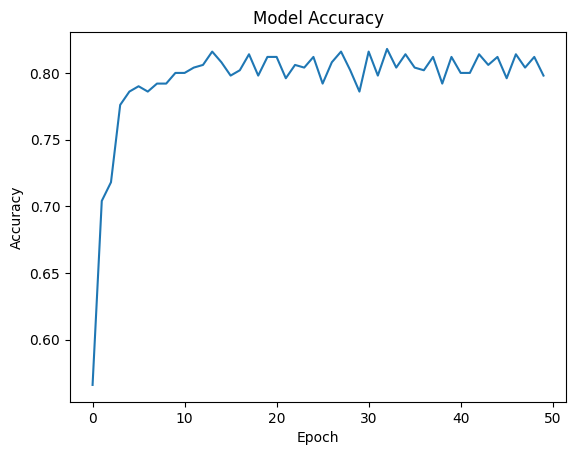

In [90]:

plt.plot(history.history['accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

In [91]:

# Example: income=0.9, credit=0.8
sample = np.array([[0.9, 0.8]])
pred = model.predict(sample)
print("Approval probability:", pred[0][0])

if pred > 0.5:
    print("Loan Approved")
else:
    print("Loan Rejected")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Approval probability: 0.9754506
Loan Approved
